#### AI/ML Project

#### Movie Recommendation System 

#### Objective

#### This project presents a Content-Based Movie Recommendation System that suggests films based on their similarity to a user-selected movie. It leverages Natural Language Processing (NLP) to extract and analyze textual features such as plot summaries, themes, and descriptions, enabling the system to identify and recommend movies with closely related content and narrative patterns.

#### Algorithm used : Content-Based Filtering + TF-IDF (Term Frequency–Inverse Document Frequency) + Cosine Similarity

In [4]:
!python -m pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


#### Importing Libraries

In [102]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

#### Loading Dataset

In [58]:
df = pd.read_csv("Movies.csv")

In [59]:
sns.set_theme(style="whitegrid")

#### Exploratory Data Analysis (EDA)

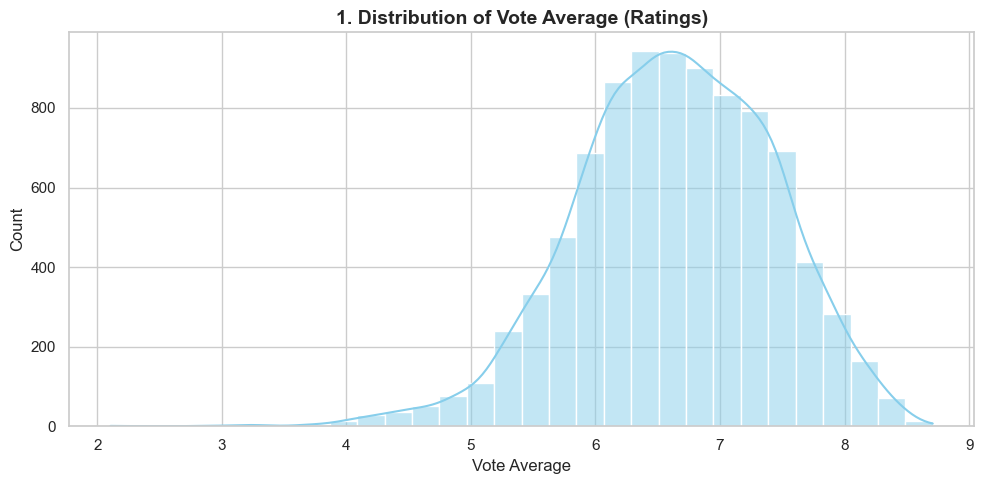

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df['vote_average'], bins=30, kde=True, color='skyblue')

plt.title('1. Distribution of Vote Average (Ratings)', fontsize=14, fontweight='bold')
plt.xlabel('Vote Average', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.savefig('1_vote_average_distribution.png', dpi=300)
plt.show()

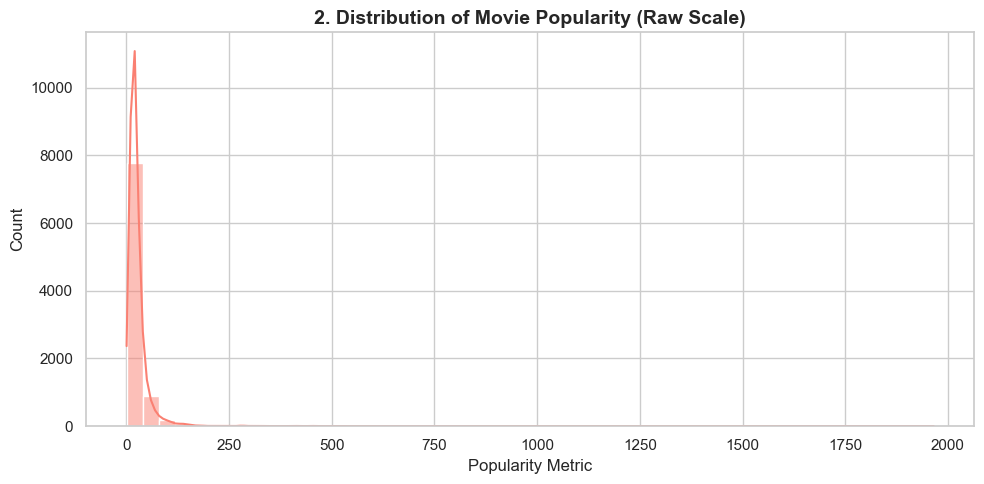

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], bins=50, kde=True, color='salmon')

plt.title('2. Distribution of Movie Popularity (Raw Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Popularity Metric', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.savefig('2_popularity_raw_distribution.png', dpi=300)
plt.show()

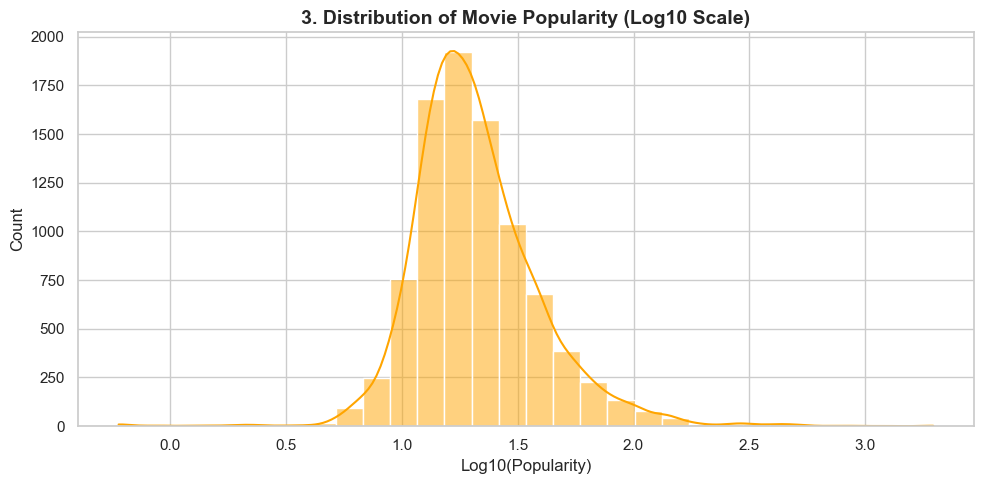

In [13]:
plt.figure(figsize=(10, 5))
# Applying log10 to the metric to handle the skewness
sns.histplot(np.log10(df['popularity']), bins=30, kde=True, color='orange')

plt.title('3. Distribution of Movie Popularity (Log10 Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Log10(Popularity)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.savefig('3_popularity_log_distribution.png', dpi=300)
plt.show()

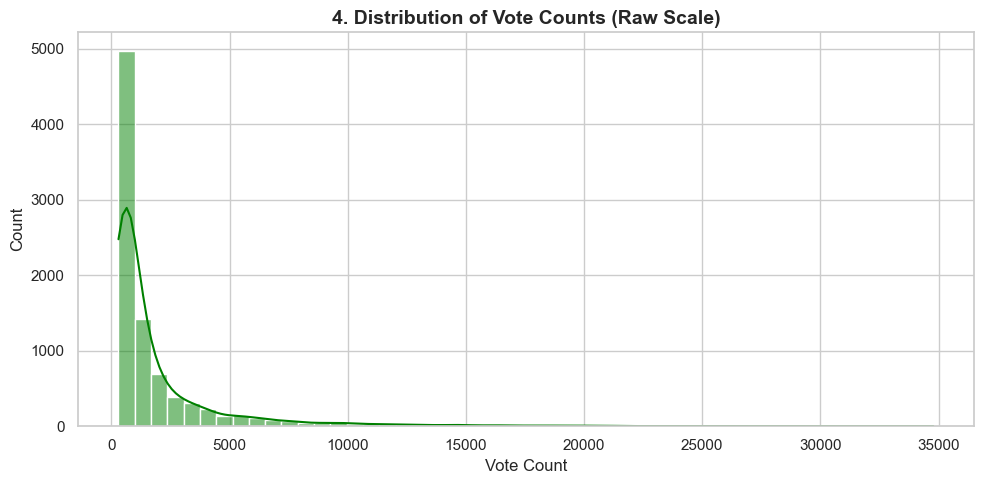

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df['vote_count'], bins=50, kde=True, color='green')

plt.title('4. Distribution of Vote Counts (Raw Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Vote Count', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.savefig('4_vote_count_raw_distribution.png', dpi=300)
plt.show()

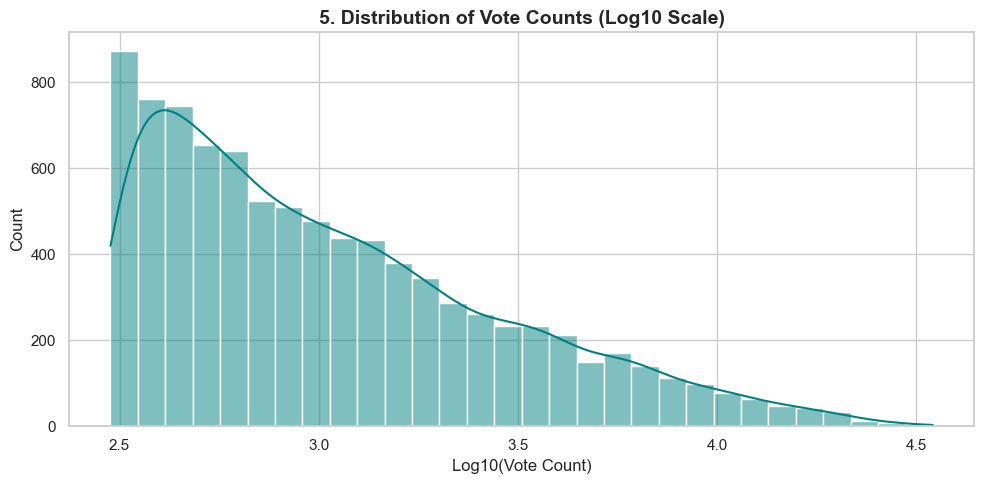

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log10(df['vote_count']), bins=30, kde=True, color='teal')

plt.title('5. Distribution of Vote Counts (Log10 Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Log10(Vote Count)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.savefig('5_vote_count_log_distribution.png', dpi=300)
plt.show()

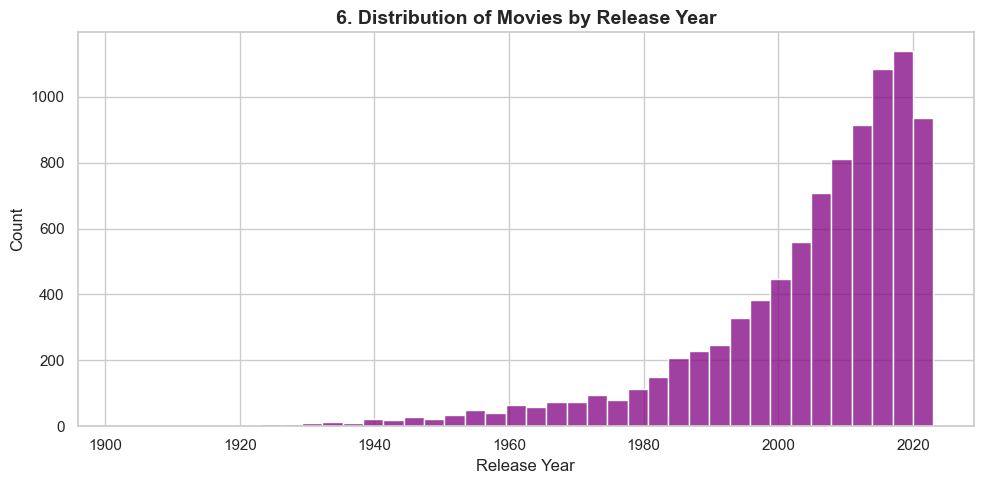

In [16]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
# Dropping empty values if any movies lack release information
sns.histplot(df['release_year'].dropna(), bins=40, kde=False, color='purple')

plt.title('6. Distribution of Movies by Release Year', fontsize=14, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.savefig('6_release_year_distribution.png', dpi=300)
plt.show()

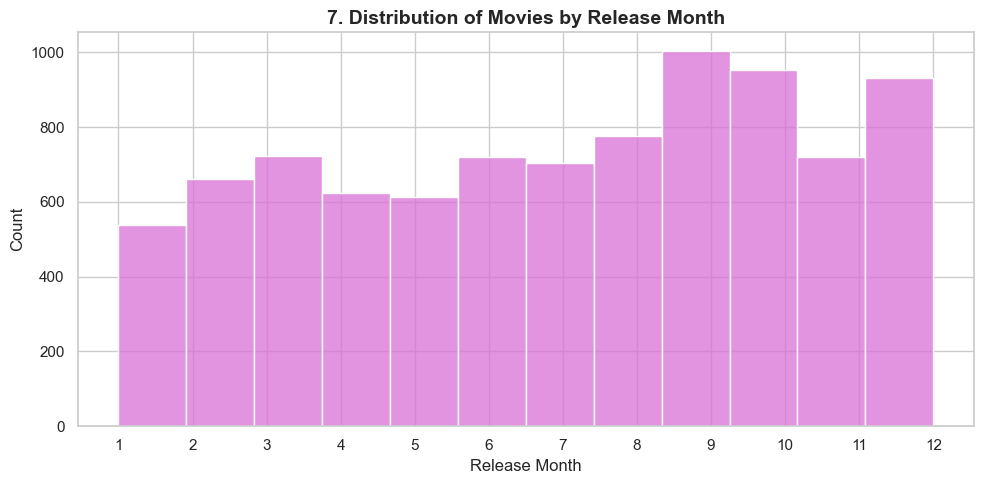

In [17]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_month'] = df['release_date'].dt.month

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(df['release_month'].dropna(), bins=12, kde=False, color='orchid')

plt.title('7. Distribution of Movies by Release Month', fontsize=14, fontweight='bold')
plt.xlabel('Release Month', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Ensure discrete month labels 1 through 12 mark the X-axis properly
plt.xticks(range(1, 13))

plt.tight_layout()
plt.savefig('7_release_month_distribution.png', dpi=300)
plt.show()

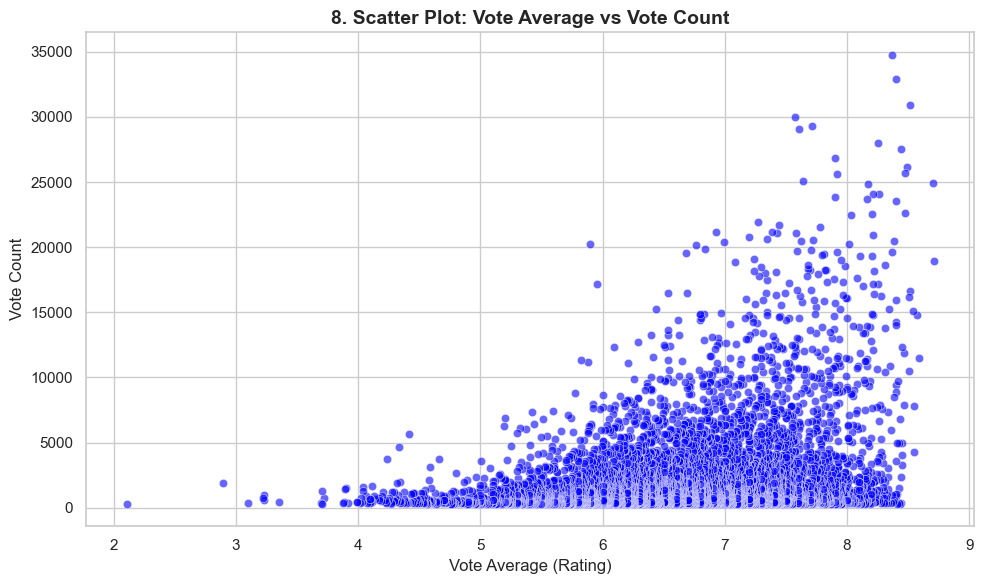

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='vote_average', y='vote_count', alpha=0.6, color='blue', ax=ax)

ax.set_title('8. Scatter Plot: Vote Average vs Vote Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Vote Average (Rating)', fontsize=12)
ax.set_ylabel('Vote Count', fontsize=12)

plt.tight_layout()
plt.savefig('5_scatter_vote_average_vs_vote_count.png', dpi=300)
plt.show()

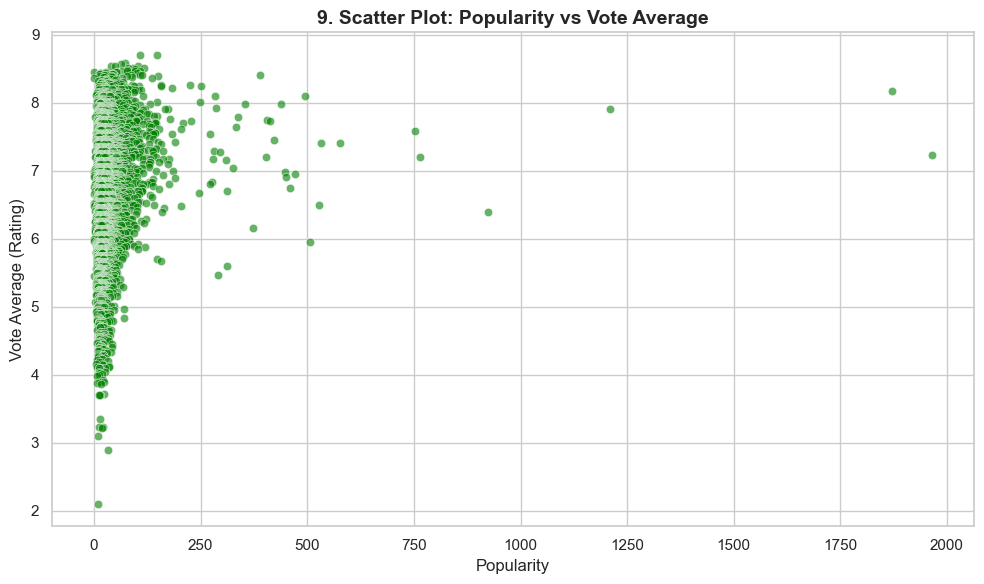

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='popularity', y='vote_average', alpha=0.6, color='green', ax=ax)

ax.set_title('9. Scatter Plot: Popularity vs Vote Average', fontsize=14, fontweight='bold')
ax.set_xlabel('Popularity', fontsize=12)
ax.set_ylabel('Vote Average (Rating)', fontsize=12)

plt.tight_layout()
plt.savefig('6_scatter_popularity_vs_vote_average.png', dpi=300)
plt.show()

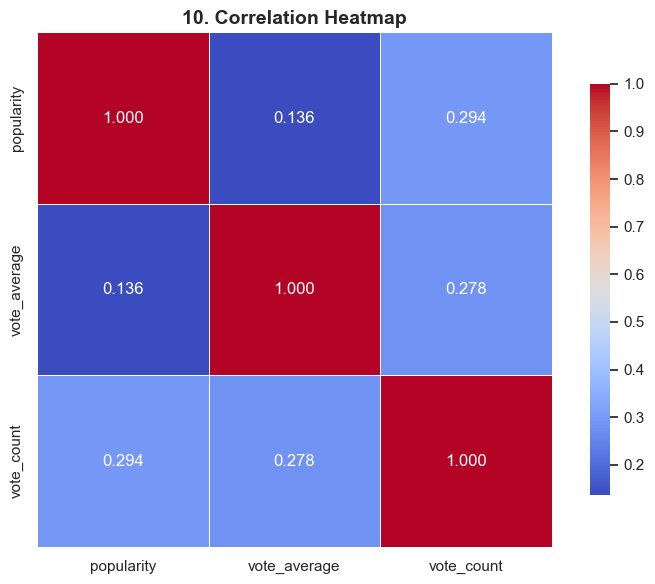

In [76]:
# Compute correlation matrix
corr_matrix = df[['popularity', 'vote_average', 'vote_count']].corr()

# Create heatmap plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=.5, square=True, cbar_kws={"shrink": .8}, ax=ax)

ax.set_title('10. Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('7_correlation_heatmap.png', dpi=300)
plt.show()

In [77]:
print(df.columns.tolist())

['Unnamed: 0', 'id', 'title', 'overview', 'release_date', 'popularity', 'vote_average', 'vote_count', 'year', 'decade']


In [78]:
df['year'] = pd.to_datetime(df['release_date']).dt.year

In [79]:
# Calculate the decade (e.g., 1995 becomes 1990)
df['decade'] = (df['year'] // 10) * 10

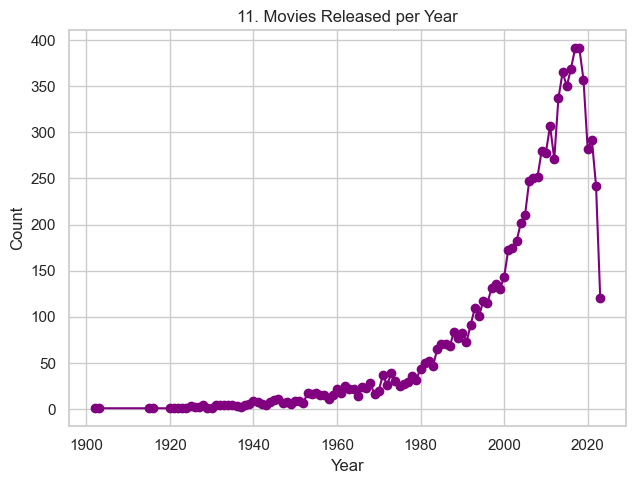

In [81]:
plt.figure(figsize=(18, 5))
#  Bar/Line - movies released per year
plt.subplot(1, 3, 1)
movies_per_year = df["year"].value_counts().sort_index()
movies_per_year.plot(kind="line", marker="o", color="purple")
plt.title("11. Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

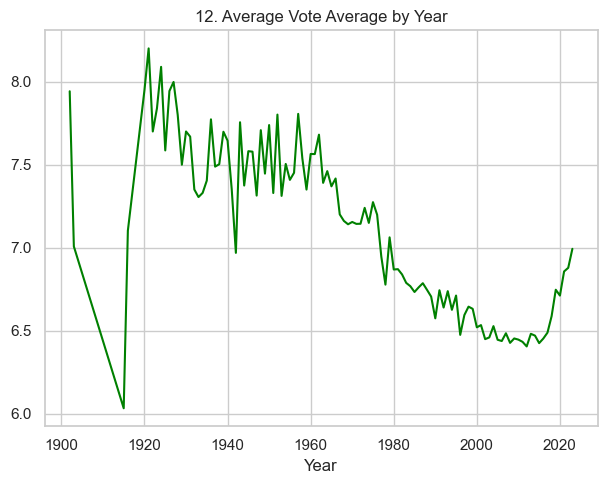

In [82]:
#  Line - average vote_average by year
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 2)
df.groupby("year")["vote_average"].mean().plot(kind="line", color="green")
plt.title("12. Average Vote Average by Year")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

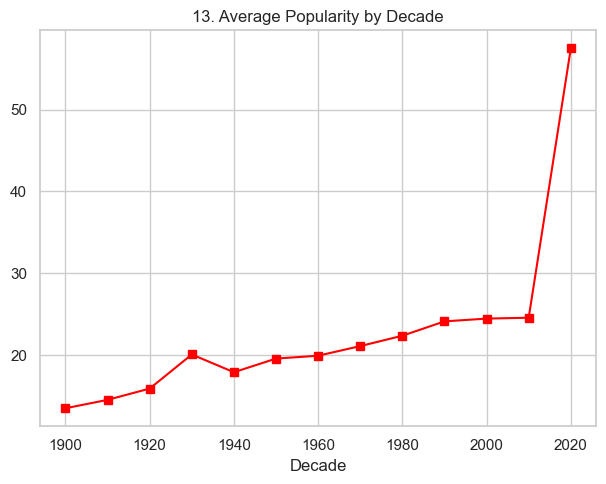

In [83]:
#  Line - average popularity by decade
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 3)
df.groupby("decade")["popularity"].mean().plot(kind="line", marker="s", color="red")
plt.title("13. Average Popularity by Decade")
plt.xlabel("Decade")
plt.tight_layout()
plt.show()

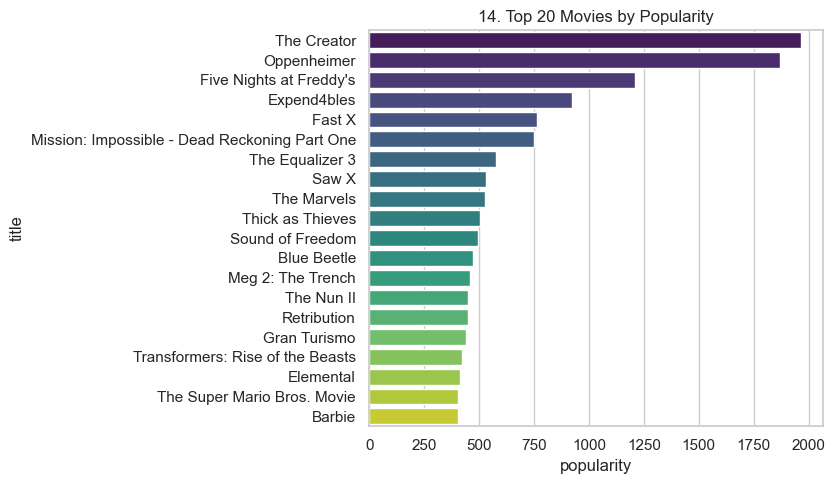

In [85]:
#  Bar - top 20 by popularity
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
top_pop = df.nlargest(20, "popularity")
sns.barplot(data=top_pop, x="popularity", y="title", hue="title", palette="viridis", legend=False)
plt.title("14. Top 20 Movies by Popularity")
plt.tight_layout()
plt.show()

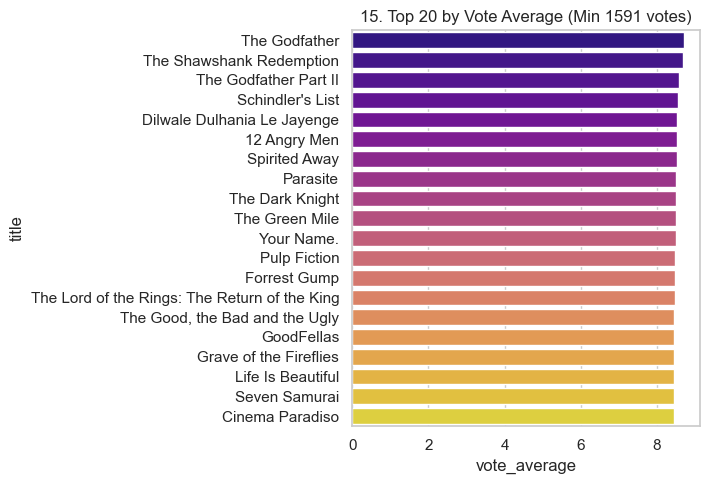

In [86]:
#  Bar - top 20 by vote_average (filtered by min vote_count)
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 2)
# Filtering out low vote counts to avoid 10/10 ratings from 1 voter
min_votes = df["vote_count"].quantile(0.70)  # Top 30% most voted movies
filtered_df = df[df["vote_count"] >= min_votes]
top_vote = filtered_df.nlargest(20, "vote_average")
sns.barplot(data=top_vote, x="vote_average", y="title", hue="title", palette="plasma", legend=False)
plt.title(f"15. Top 20 by Vote Average (Min {int(min_votes)} votes)")

plt.tight_layout()
plt.show()

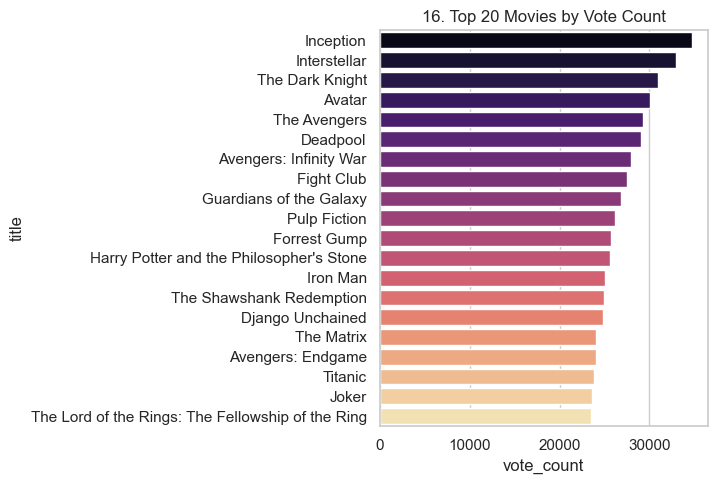

In [87]:
plt.figure(figsize=(18, 5))
#  Bar - top 20 by vote_count
plt.subplot(1, 3, 3)
top_count = df.nlargest(20, "vote_count")
sns.barplot(data=top_count, x="vote_count", y="title", hue="title", palette="magma", legend=False)
plt.title("16. Top 20 Movies by Vote Count")

plt.tight_layout()
plt.show()

In [98]:
#  TEXT (OVERVIEW)
from collections import Counter
import re

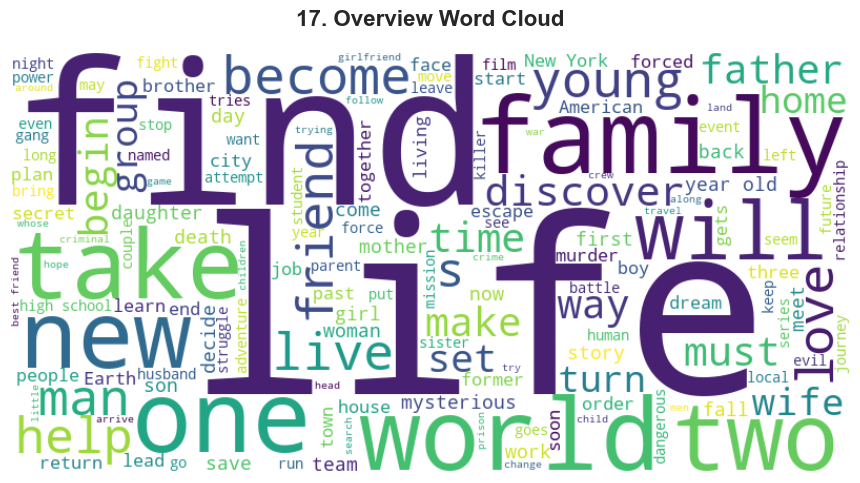

In [103]:
# Extract and combine all text overviews into a single string
text = " ".join(df["overview"].dropna().astype(str))

custom_stopwords = set(STOPWORDS)

wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color="white",
    stopwords=custom_stopwords,
    colormap='viridis',      
    max_words=150,           
    random_state=42          
).generate(text)

# 5. Render and display the plot using Matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear") # Smooths out text pixelation
plt.axis("off") # Hides the X and Y axes coordinates

plt.title("17. Overview Word Cloud", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('17_overview_wordcloud.png', dpi=300)
plt.show()

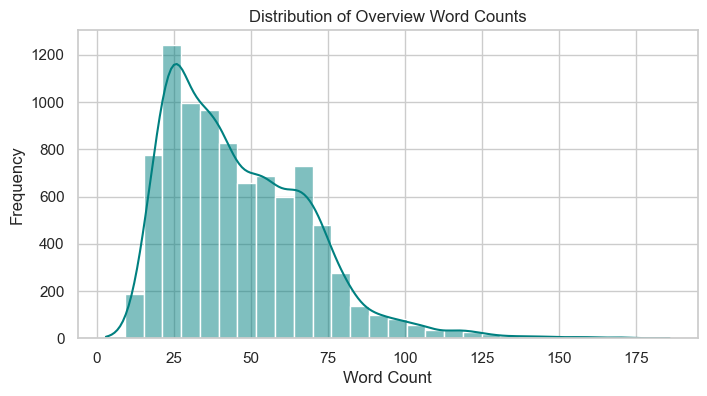

In [91]:
# Histogram - overview length (word count)
plt.figure(figsize=(8, 4))
overview_lengths = df["overview"].dropna().apply(lambda x: len(x.split()))
sns.histplot(overview_lengths, bins=30, kde=True, color="teal")
plt.title("18. Distribution of Overview Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

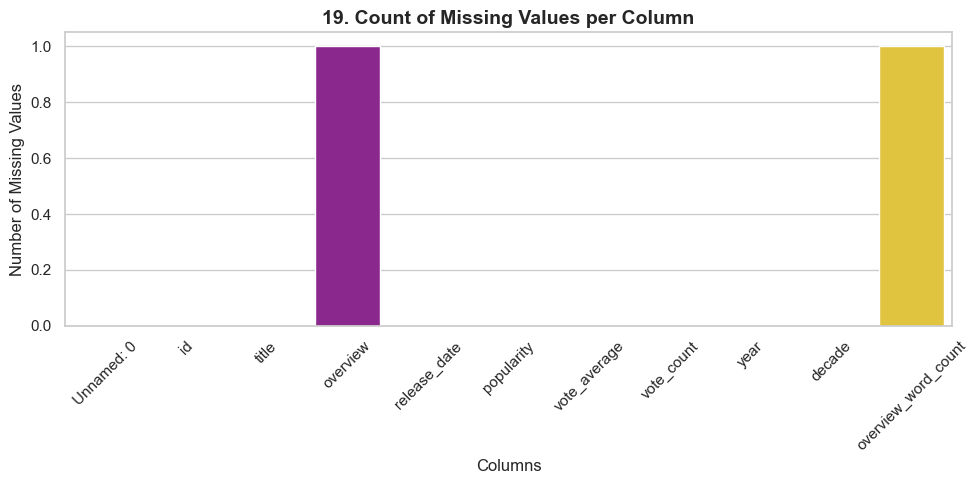

In [104]:
missing_counts = df.isnull().sum()

plt.figure(figsize=(10, 5))
# Assign x to hue and set legend=False to keep the same look without warnings
sns.barplot(
    x=missing_counts.index, 
    y=missing_counts.values, 
    hue=missing_counts.index, 
    palette='plasma', 
    legend=False
)

plt.title('19. Count of Missing Values per Column', fontsize=14, fontweight='bold')
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Number of Missing Values', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('16_missing_values_bar_chart.png', dpi=300)
plt.show()

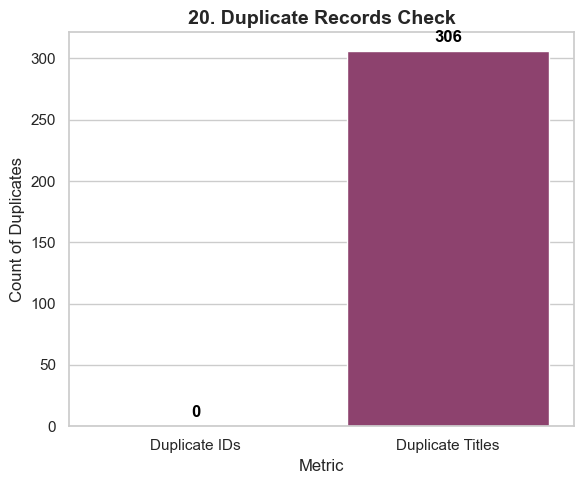

In [105]:
duplicate_ids = df.duplicated(subset=['id']).sum()
duplicate_titles = df.duplicated(subset=['title']).sum()

dup_df = pd.DataFrame({
    'Metric': ['Duplicate IDs', 'Duplicate Titles'],
    'Count': [duplicate_ids, duplicate_titles]
})

plt.figure(figsize=(6, 5))
sns.barplot(
    data=dup_df, 
    x='Metric', 
    y='Count', 
    hue='Metric', 
    palette='flare', 
    legend=False
)
plt.title('20. Duplicate Records Check', fontsize=14, fontweight='bold')
plt.ylabel('Count of Duplicates', fontsize=12)

for index, row in dup_df.iterrows():
    plt.text(index, row['Count'] + 5, str(int(row['Count'])), 
             color='black', ha="center", va="bottom", fontweight='bold')

plt.tight_layout()
plt.savefig('17_duplicate_check_chart.png', dpi=300)
plt.show()

#### Import Libraries

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#### Load Dataset

In [44]:
df = pd.read_csv("Movies.csv")

df

,Unnamed: 0,id,title,overview,release_date,popularity,vote_average,vote_count
0,0,238,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,147.852,8.708,18973
1,1,278,The Shawshank Redemption,Framed in the 1940s for the double murder of h...,1994-09-23,107.671,8.705,24959
2,2,240,The Godfather Part II,In the continuing saga of the Corleone crime f...,1974-12-20,72.789,8.589,11455
3,3,424,Schindler's List,The true story of how businessman Oskar Schind...,1993-12-15,64.226,8.571,14802
4,4,19404,Dilwale Dulhania Le Jayenge,"Raj is a rich, carefree, happy-go-lucky second...",1995-10-20,39.926,8.547,4278
...,...,...,...,...,...,...,...,...
8960,8960,12142,Alone in the Dark,Edward Carnby is a private investigator specia...,2005-01-28,12.475,3.228,550
8961,8961,5491,Battlefield Earth,"In the year 3000, man is no match for the Psyc...",2000-05-12,18.015,3.223,760
8962,8962,11059,House of the Dead,"Set on an island off the coast, a techno rave ...",2003-04-11,9.392,3.100,359
8963,8963,14164,Dragonball Evolution,"On his 18th birthday, Goku receives a mystical...",2009-03-12,33.435,2.892,1925


In [45]:
df.head()

,Unnamed: 0,id,title,overview,release_date,popularity,vote_average,vote_count
0,0,238,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,147.852,8.708,18973
1,1,278,The Shawshank Redemption,Framed in the 1940s for the double murder of h...,1994-09-23,107.671,8.705,24959
2,2,240,The Godfather Part II,In the continuing saga of the Corleone crime f...,1974-12-20,72.789,8.589,11455
3,3,424,Schindler's List,The true story of how businessman Oskar Schind...,1993-12-15,64.226,8.571,14802
4,4,19404,Dilwale Dulhania Le Jayenge,"Raj is a rich, carefree, happy-go-lucky second...",1995-10-20,39.926,8.547,4278


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8965 entries, 0 to 8964
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    8965 non-null   int64  
 1   id            8965 non-null   int64  
 2   title         8965 non-null   object 
 3   overview      8964 non-null   object 
 4   release_date  8965 non-null   object 
 5   popularity    8965 non-null   float64
 6   vote_average  8965 non-null   float64
 7   vote_count    8965 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 560.4+ KB


In [47]:
df.describe()

,Unnamed: 0,id,popularity,vote_average,vote_count
count,8965.000000,8.965000e+03,8965.000000,8965.000000,8965.000000
mean,4482.000000,1.773897e+05,27.379618,6.635782,1960.394423
std,2588.116915,2.351157e+05,45.458358,0.794322,3046.827125
min,0.000000,5.000000e+00,0.600000,2.106000,300.000000
25%,2241.000000,9.912000e+03,14.113000,6.110000,469.000000
50%,4482.000000,3.354200e+04,19.257000,6.659000,844.000000
75%,6723.000000,3.345220e+05,28.733000,7.205000,1957.000000
max,8964.000000,1.151534e+06,1965.179000,8.708000,34776.000000


#### Data Preprocessing

In [10]:
# Keep only required columns

movies = df[['title', 'overview']]

# Remove missing values

movies = movies.dropna()

movies.reset_index(drop=True, inplace=True)

movies.head()

,title,overview
0,The Godfather,"Spanning the years 1945 to 1955, a chronicle o..."
1,The Shawshank Redemption,Framed in the 1940s for the double murder of h...
2,The Godfather Part II,In the continuing saga of the Corleone crime f...
3,Schindler's List,The true story of how businessman Oskar Schind...
4,Dilwale Dulhania Le Jayenge,"Raj is a rich, carefree, happy-go-lucky second..."


#### TF-IDF Vectorization

In [11]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(movies['overview'])

print(tfidf_matrix.shape)

(8964, 5000)


#### Cosine Similarity Matrix 

In [12]:
cosine_sim = cosine_similarity(tfidf_matrix)

print(cosine_sim.shape)

(8964, 8964)


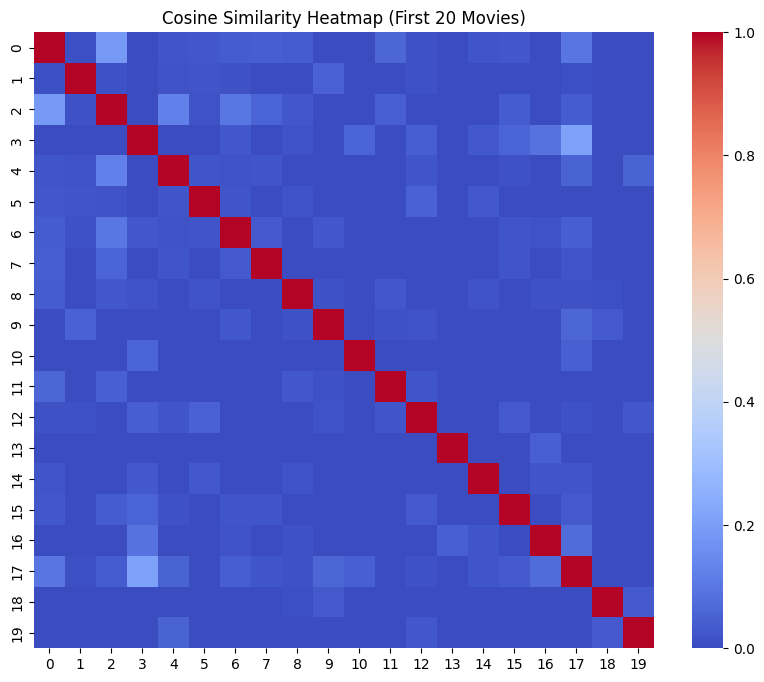

In [14]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cosine_sim[:20, :20],
    cmap='coolwarm'
)

plt.title("Cosine Similarity Heatmap (First 20 Movies)")
plt.show()

#### Create Movie Index Mapping

In [15]:
movie_indices = pd.Series(
    movies.index,
    index=movies['title']
).drop_duplicates()

movie_indices.head()

title
The Godfather                  0
The Shawshank Redemption       1
The Godfather Part II          2
Schindler's List               3
Dilwale Dulhania Le Jayenge    4
dtype: int64

#### Recommendation Function

In [52]:
def recommend_movies(movie_title, n=10):
    
    movie_title = movie_title.strip()

    
    if movie_title not in movie_indices:
        print(f"Error: '{movie_title}' not found in dataset.")
        # Return an empty DataFrame with the correct columns so your plot code doesn't crash completely
        return pd.DataFrame(columns=['Movie', 'Similarity Score'])

    
    idx = movie_indices[movie_title]
    sim_scores = list(enumerate(cosine_sim[idx]))

    
    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )[1:n+1]

    movie_idx = [i[0] for i in sim_scores]


    recommendations = pd.DataFrame({
        'Movie': movies['title'].iloc[movie_idx],
        'Similarity Score': [i[1] for i in sim_scores]
    })

    return recommendations

#### Testing the Model

### Rules: Enter the name of your favourite movie in the variable "movie" but given the condition that the movie should exist in the dataset.

type the name of your favourite movie: The Dark Knight


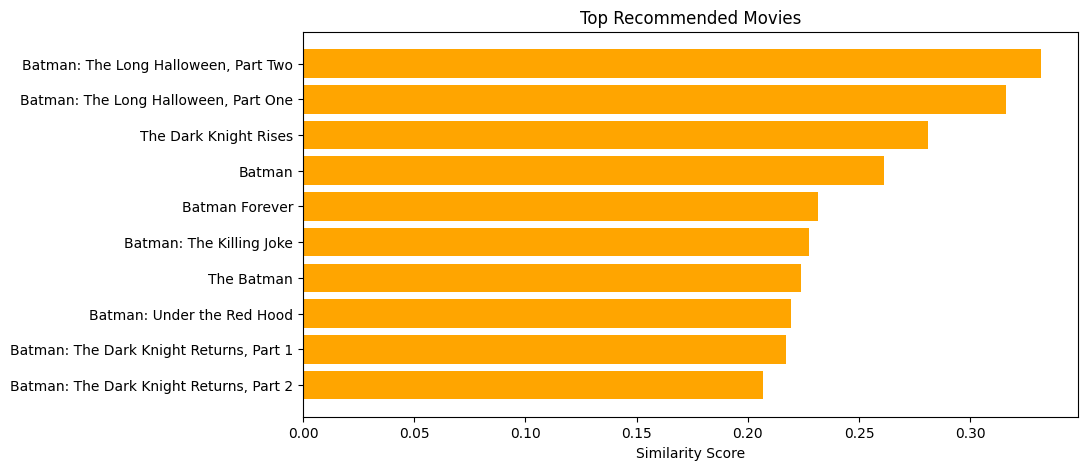

In [56]:

movie=input("type the name of your favourite movie:")

result = recommend_movies(f"{movie}")

# Plotting the results
if not result.empty:
    plt.figure(figsize=(10, 5))
    plt.barh(
        result['Movie'],
        result['Similarity Score'],
        color='orange' # Added a nice color touch!
    )
    plt.xlabel("Similarity Score")
    plt.title("Top Recommended Movies")
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("Could not generate plot because the movie was not found.")